In [1]:
import pandas as pd
import numpy as np
import spacy
import unicodedata
import math
from collections import Counter

In [2]:
nlp = spacy.load("en_core_web_md")

In [3]:
def normalizar_texto(texto):
    if pd.isna(texto):
        return ""

    texto = str(texto)
    texto = unicodedata.normalize("NFC", texto)

    texto = texto.replace("\ufeff", "")
    texto = texto.replace("\u200b", "")
    texto = texto.replace("\xa0", " ")

    texto = " ".join(texto.split())

    return texto.strip()

In [4]:
def safe_div(num, den):
    return num / den if den else np.nan

In [5]:
def lexical_diversity_metrics(words):
    words_lower = [w.lower() for w in words]
    n_tokens = len(words_lower)
    freqs = Counter(words_lower)
    n_types = len(freqs)

    if n_tokens == 0:
        return {
            "n_types": 0,
            "ttr": np.nan,
            "root_ttr": np.nan,
            "corrected_ttr": np.nan,
            "guiraud": np.nan,
            "herdan_c": np.nan,
            "honore_r": np.nan,
            "yule_k": np.nan,
        }

    v1 = sum(1 for f in freqs.values() if f == 1)

    ttr = n_types / n_tokens
    root_ttr = n_types / math.sqrt(n_tokens)
    corrected_ttr = n_types / math.sqrt(2 * n_tokens)
    guiraud = n_types / math.sqrt(n_tokens)

    herdan_c = (
        math.log(n_types) / math.log(n_tokens)
        if n_types > 1 and n_tokens > 1
        else np.nan
    )

    honore_r = (
        100 * math.log(n_tokens) / (1 - v1 / n_types)
        if n_types > 0 and v1 < n_types and n_tokens > 1
        else np.nan
    )

    m2 = sum(f ** 2 for f in freqs.values())
    yule_k = 10000 * (m2 - n_tokens) / (n_tokens ** 2)

    return {
        "n_types": n_types,
        "ttr": ttr,
        "root_ttr": root_ttr,
        "corrected_ttr": corrected_ttr,
        "guiraud": guiraud,
        "herdan_c": herdan_c,
        "honore_r": honore_r,
        "yule_k": yule_k,
    }

In [6]:
def extraer_rasgos_spacy(doc):
    tokens = [t for t in doc if not t.is_space]
    words = [t for t in doc if t.is_alpha]
    sentences = list(doc.sents)

    word_texts = [t.text for t in words]
    lemmas = [t.lemma_.lower() for t in words]

    n_tokens = len(tokens)
    n_words = len(words)
    n_sentences = len(sentences)

    pos_counts = Counter(t.pos_ for t in words)
    dep_counts = Counter(t.dep_ for t in words)

    lexical = lexical_diversity_metrics(word_texts)

    n_lexical_words = (
        pos_counts["NOUN"]
        + pos_counts["VERB"]
        + pos_counts["ADJ"]
        + pos_counts["ADV"]
        + pos_counts["PROPN"]
    )

    n_function_words = n_words - n_lexical_words

    n_subordinate = (
        dep_counts["advcl"]
        + dep_counts["ccomp"]
        + dep_counts["xcomp"]
        + dep_counts["relcl"]
        + dep_counts["acl"]
    )

    n_coordination = pos_counts["CCONJ"]

    n_finite_verbs = sum(
        1 for t in words
        if t.pos_ in ["VERB", "AUX"] and "Fin" in t.morph.get("VerbForm")
    )

    n_past = sum(
        1 for t in words
        if "Past" in t.morph.get("Tense")
    )

    n_present = sum(
        1 for t in words
        if "Pres" in t.morph.get("Tense")
    )

    n_plural = sum(
        1 for t in words
        if "Plur" in t.morph.get("Number")
    )

    n_singular = sum(
        1 for t in words
        if "Sing" in t.morph.get("Number")
    )

    return {
        "n_tokens": n_tokens,
        "n_words": n_words,
        "n_sentences": n_sentences,

        **lexical,

        "mean_word_length": np.mean([len(t.text) for t in words]) if words else np.nan,
        "mean_sentence_length": safe_div(n_words, n_sentences),

        "n_lexical_words": n_lexical_words,
        "n_function_words": n_function_words,
        "lexical_density": safe_div(n_lexical_words, n_words),

        "n_nouns": pos_counts["NOUN"],
        "n_proper_nouns": pos_counts["PROPN"],
        "n_verbs": pos_counts["VERB"],
        "n_aux": pos_counts["AUX"],
        "n_adj": pos_counts["ADJ"],
        "n_adv": pos_counts["ADV"],
        "n_pron": pos_counts["PRON"],
        "n_det": pos_counts["DET"],
        "n_adp": pos_counts["ADP"],
        "n_num": pos_counts["NUM"],
        "n_conj": pos_counts["CCONJ"] + pos_counts["SCONJ"],

        "prop_nouns": safe_div(pos_counts["NOUN"], n_words),
        "prop_verbs": safe_div(pos_counts["VERB"], n_words),
        "prop_aux": safe_div(pos_counts["AUX"], n_words),
        "prop_adj": safe_div(pos_counts["ADJ"], n_words),
        "prop_adv": safe_div(pos_counts["ADV"], n_words),
        "prop_pron": safe_div(pos_counts["PRON"], n_words),
        "prop_det": safe_div(pos_counts["DET"], n_words),
        "prop_adp": safe_div(pos_counts["ADP"], n_words),

        "n_subjects": dep_counts["nsubj"] + dep_counts["nsubjpass"],
        "n_objects": dep_counts["dobj"] + dep_counts["obj"],
        "n_amod": dep_counts["amod"],
        "n_advmod": dep_counts["advmod"],
        "n_compounds": dep_counts["compound"],
        "n_preps": dep_counts["prep"],

        "n_subordinate_clauses": n_subordinate,
        "subordination_ratio": safe_div(n_subordinate, n_sentences),

        "n_coordination": n_coordination,
        "coordination_ratio": safe_div(n_coordination, n_sentences),

        "n_finite_verbs": n_finite_verbs,
        "finite_verbs_per_sentence": safe_div(n_finite_verbs, n_sentences),

        "n_past": n_past,
        "n_present": n_present,
        "n_plural": n_plural,
        "n_singular": n_singular,

        "past_ratio": safe_div(n_past, n_words),
        "present_ratio": safe_div(n_present, n_words),
        "plural_ratio": safe_div(n_plural, n_words),
    }

In [7]:
corpus = pd.read_csv("corpus_inmersia_0.csv")

In [8]:
corpus["text_norm"] = corpus["text_full"].apply(normalizar_texto)

docs = list(
    nlp.pipe(
        corpus["text_norm"],
        batch_size=50
    )
)

features = pd.DataFrame(
    [extraer_rasgos_spacy(doc) for doc in docs]
)

corpus_features = pd.concat(
    [
        corpus.reset_index(drop=True),
        features.reset_index(drop=True)
    ],
    axis=1
)

In [9]:
corpus_features["tokens"] = [
    [t.text for t in doc if not t.is_space]
    for doc in docs
]

corpus_features["tokens_alpha"] = [
    [t.text for t in doc if t.is_alpha]
    for doc in docs
]

corpus_features["lemmas"] = [
    [t.lemma_.lower() for t in doc if t.is_alpha]
    for doc in docs
]

corpus_features["pos"] = [
    [t.pos_ for t in doc if not t.is_space]
    for doc in docs
]

corpus_features["dep"] = [
    [t.dep_ for t in doc if not t.is_space]
    for doc in docs
]

corpus_features["text_lemmas"] = [
    " ".join([t.lemma_.lower() for t in doc if t.is_alpha])
    for doc in docs
]

In [10]:
corpus_features[
    [
        "doc_name",
        "n_words",
        "n_sentences",
        "mean_sentence_length",
        "lexical_density",
        "ttr",
        "guiraud",
        "herdan_c",
        "n_subordinate_clauses",
        "subordination_ratio"
    ]
].head()

,doc_name,n_words,n_sentences,mean_sentence_length,lexical_density,ttr,guiraud,herdan_c,n_subordinate_clauses,subordination_ratio
0,GN_doc_1,158,15,10.533333,0.518987,0.550633,6.921348,0.882138,15,1.000000
1,GN_doc_2,155,13,11.923077,0.522581,0.541935,6.747042,0.878533,11,0.846154
2,GN_doc_3,179,11,16.272727,0.486034,0.452514,6.054224,0.847141,18,1.636364
3,GN_doc_4,168,5,33.600000,0.500000,0.565476,7.329409,0.888741,17,3.400000
4,GN_doc_5,145,14,10.357143,0.427586,0.613793,7.391048,0.901924,5,0.357143


In [11]:
corpus_features.to_csv(
    "corpus_inmersia_cf2.csv",
    index=False
)

In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ---------- PALETA ----------
BLUE = "#4C78A8"
CORAL = "#E76F51"
TEAL = "#2A9D8F"
GOLD = "#E9C46A"
GREY_DARK = "#2F3E46"
GREY_MID = "#6B7280"
GREY_LIGHT = "#E5E7EB"
BG = "white"

# ---------- TEMA GLOBAL ----------
sns.set_theme(style="whitegrid")

mpl.rcParams.update({
    # Figura
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "figure.dpi": 120,

    # Tipografía
    "font.family": "DejaVu Sans",   # si tienes Helvetica/Avenir puedes cambiarla aquí
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Colores de texto
    "text.color": GREY_DARK,
    "axes.labelcolor": GREY_DARK,
    "axes.titlecolor": GREY_DARK,
    "xtick.color": GREY_MID,
    "ytick.color": GREY_MID,

    # Ejes / grid
    "axes.edgecolor": BG,      # oculta caja
    "axes.linewidth": 0.0,
    "grid.color": GREY_LIGHT,
    "grid.linewidth": 0.8,
    "grid.alpha": 0.8,
    "axes.grid": True,
    "axes.axisbelow": True,

    # Leyenda
    "legend.frameon": False,
})

In [19]:
def style_ax(ax, title=None, subtitle=None, xlabel=None, ylabel=None):
    # quitar spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # títulos
    if title:
        ax.set_title(title, loc="left", pad=16)
    if subtitle:
        ax.text(
            0, 1.02, subtitle,
            transform=ax.transAxes,
            ha="left", va="bottom",
            fontsize=10, color=GREY_MID
        )

    # etiquetas
    if xlabel:
        ax.set_xlabel(xlabel, labelpad=10)
    if ylabel:
        ax.set_ylabel(ylabel, labelpad=10)

    return ax

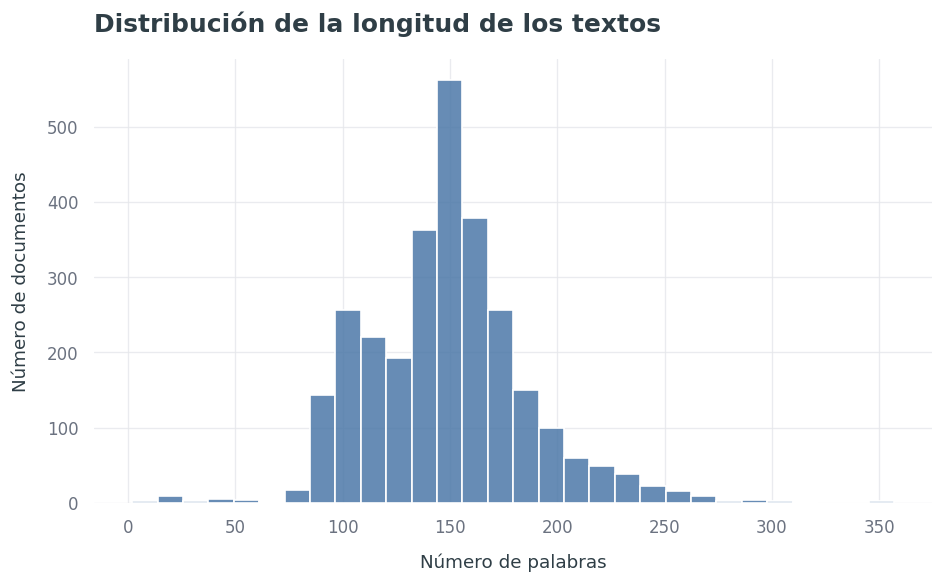

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    corpus_features["n_words"].dropna(),
    bins=30,
    color=BLUE,
    alpha=0.85,
    edgecolor=None,
    ax=ax
)

style_ax(
    ax,
    title="Distribución de la longitud de los textos",
    xlabel="Número de palabras",
    ylabel="Número de documentos"
)

plt.tight_layout()
plt.show()

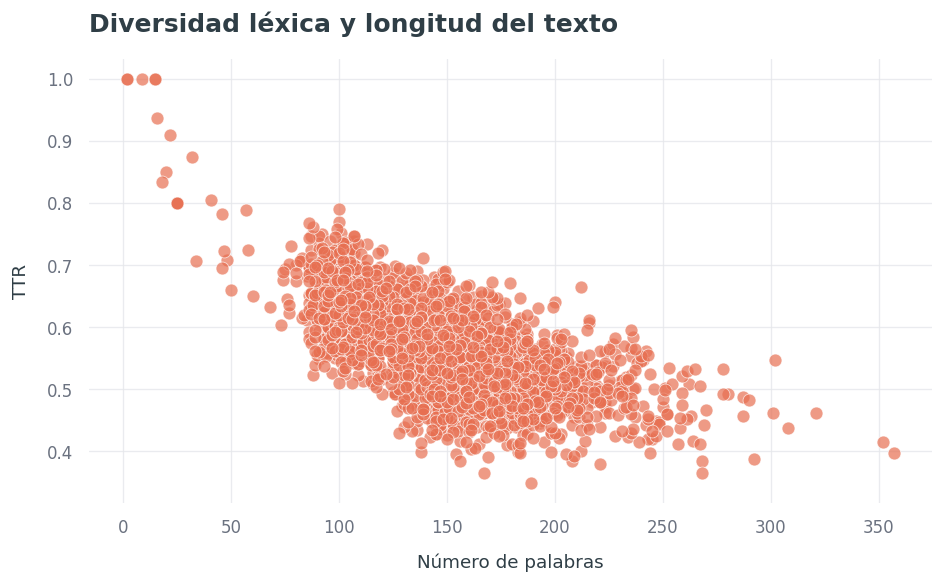

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=corpus_features,
    x="n_words",
    y="ttr",
    s=60,
    alpha=0.7,
    color=CORAL,
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

style_ax(
    ax,
    title="Diversidad léxica y longitud del texto",
    xlabel="Número de palabras",
    ylabel="TTR"
)

plt.tight_layout()
plt.show()

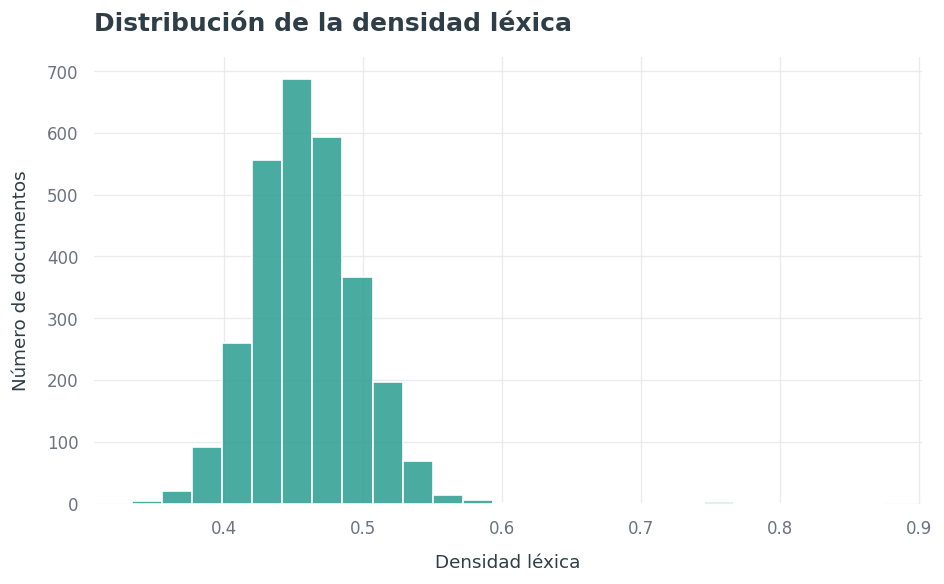

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    corpus_features["lexical_density"].dropna(),
    bins=25,
    color=TEAL,
    alpha=0.85,
    edgecolor=None,
    ax=ax
)

style_ax(
    ax,
    title="Distribución de la densidad léxica",
    xlabel="Densidad léxica",
    ylabel="Número de documentos"
)

plt.tight_layout()
plt.show()

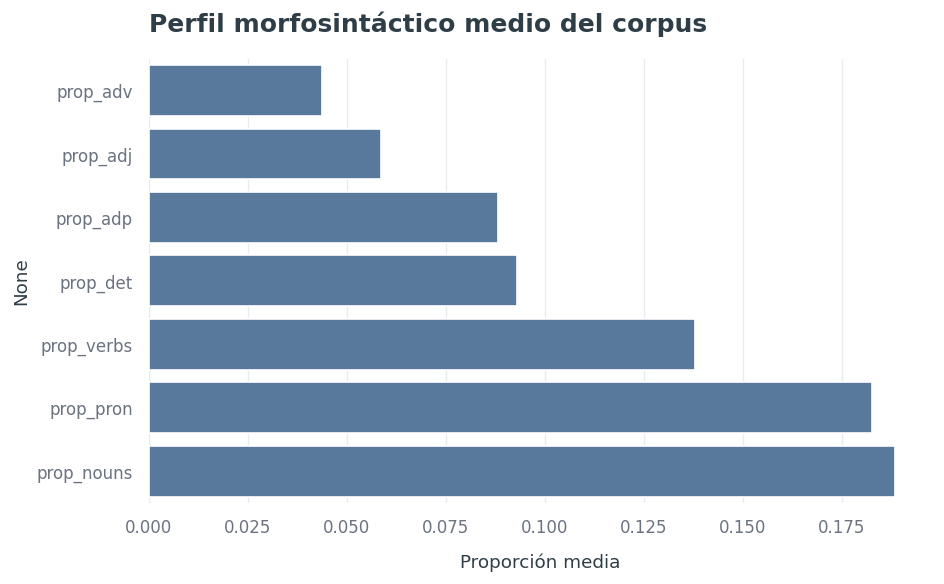

In [30]:
pos_cols = [
    "prop_nouns",
    "prop_verbs",
    "prop_adj",
    "prop_adv",
    "prop_pron",
    "prop_det",
    "prop_adp"
]

pos_means = corpus_features[pos_cols].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=pos_means.values,
    y=pos_means.index,
    color=BLUE,
    ax=ax
)

style_ax(
    ax,
    title="Perfil morfosintáctico medio del corpus",
    xlabel="Proporción media",
    ylabel=""
)

plt.tight_layout()
plt.show()

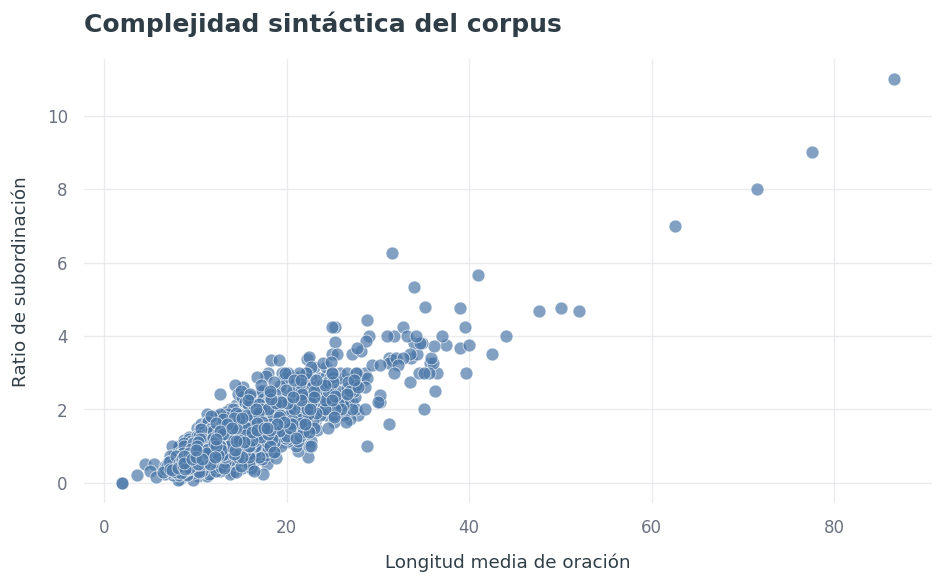

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=corpus_features,
    x="mean_sentence_length",
    y="subordination_ratio",
    s=60,
    alpha=0.7,
    color=BLUE,
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

style_ax(
    ax,
    title="Complejidad sintáctica del corpus",
    xlabel="Longitud media de oración",
    ylabel="Ratio de subordinación"
)

plt.tight_layout()
plt.show()

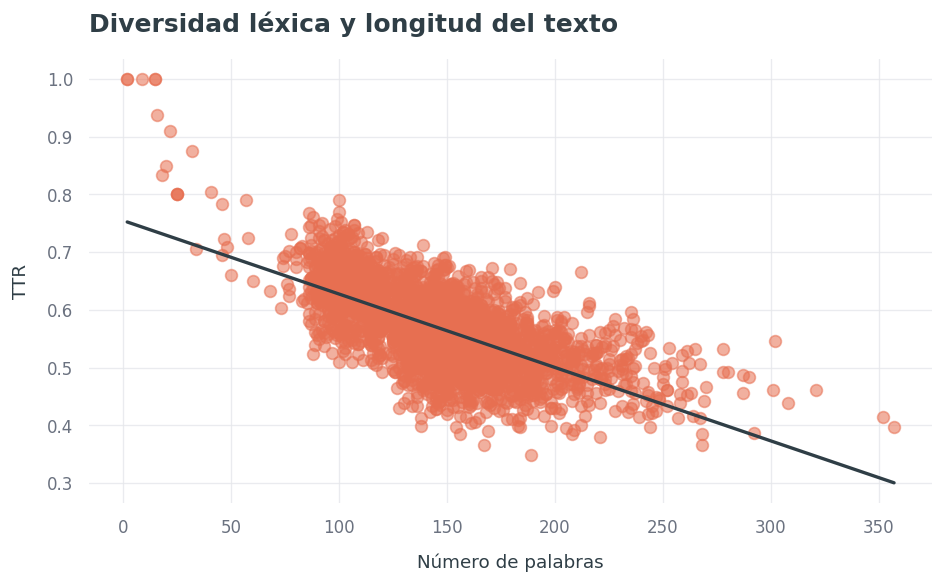

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.regplot(
    data=corpus_features,
    x="n_words",
    y="ttr",
    scatter_kws={"s": 50, "alpha": 0.55, "color": CORAL},
    line_kws={"color": GREY_DARK, "linewidth": 2},
    ci=None,
    ax=ax
)

style_ax(
    ax,
    title="Diversidad léxica y longitud del texto",
    xlabel="Número de palabras",
    ylabel="TTR"
)

plt.tight_layout()
plt.show()